# Notebook 03: Evaluation Metrics

**Runs on:** Local machine (no GPU needed)

**Prerequisites:** Download `training_results.zip` from Colab (Notebook 02) and extract to `Phase2_DL/experiments/results/`

This notebook:
- Loads trained model weights
- Evaluates all models on the held-out test set
- Computes accuracy, F1, precision, recall per class
- Generates confusion matrices
- Produces a comparison summary table

In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, f1_score
)
from collections import Counter
import timm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')  # No GPU needed for evaluation

# Paths
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'experiments', 'results')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

print(f"Looking for models in: {MODELS_DIR}")
if os.path.exists(MODELS_DIR):
    print(f"Found: {os.listdir(MODELS_DIR)}")
else:
    print("ERROR: Models directory not found. Extract training_results.zip first.")

Looking for models in: /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/models
Found: ['SimpleCNN.pth', 'ViT_Small.pth', 'ResNet50_SE.pth', 'ResNet50_SSAM.pth']


## 1. Load Dataset and Recreate Test Split

In [ ]:
raw_dataset = EuroSAT(root=DATA_DIR, download=True)

CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Recreate same split
all_indices = list(range(len(raw_dataset)))
all_labels = [raw_dataset[i][1] for i in all_indices]
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels
)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

# Test dataset and loader
class EuroSATSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform: img = self.transform(img)
        return img, label

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = EuroSATSubset(raw_dataset, test_idx, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Test set: {len(test_idx)} images")

Test set: 4050 images


## 2. Load Model Architectures

We need to define the same architectures to load the saved weights.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, num_classes))
    def forward(self, x):
        x = self.features(x).view(x.size(0), -1)
        return self.classifier(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(True),
            nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SSAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.channel_mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=spatial_kernel, padding=spatial_kernel // 2, bias=False),
            nn.BatchNorm2d(1),
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.channel_mlp(self.avg_pool(x).view(b, c))
        max_out = self.channel_mlp(self.max_pool(x).view(b, c))
        x = x * torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        avg_s = torch.mean(x, dim=1, keepdim=True)
        max_s, _ = torch.max(x, dim=1, keepdim=True)
        x = x * torch.sigmoid(self.spatial_conv(torch.cat([avg_s, max_s], dim=1)))
        return x

class ResNetSE(nn.Module):
    def __init__(self, num_classes=10, pretrained=False, use_se=True):
        super().__init__()
        self.use_se = use_se
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        if use_se: self.se_block = SEBlock(2048, 16)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(2048, 512), nn.ReLU(True), nn.Dropout(0.2), nn.Linear(512, num_classes)
        )
    def forward(self, x):
        f = self.backbone.forward_features(x)
        if self.use_se: f = self.se_block(f)
        return self.classifier(F.adaptive_avg_pool2d(f, 1).flatten(1))

class ViTSmall(nn.Module):
    def __init__(self, num_classes=10, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model('vit_small_patch16_224', pretrained=pretrained, num_classes=0, img_size=64)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(self.backbone.embed_dim, num_classes))
    def forward(self, x): return self.classifier(self.backbone(x))

class ResNetSSAM(nn.Module):
    def __init__(self, num_classes=10, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        self.ssam = SSAM(2048, 16, 7)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(2048, 512), nn.ReLU(True), nn.Dropout(0.2), nn.Linear(512, num_classes)
        )
    def forward(self, x):
        f = self.ssam(self.backbone.forward_features(x))
        return self.classifier(F.adaptive_avg_pool2d(f, 1).flatten(1))

print("Model architectures defined.")

Model architectures defined.


## 3. Load Weights and Evaluate

In [ ]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


# Load and evaluate each model
model_configs = {
    'Simple CNN': ('SimpleCNN.pth', SimpleCNN),
    'ResNet-50+SE': ('ResNet50_SE.pth', lambda: ResNetSE(pretrained=False, use_se=True)),
    'ViT-Small': ('ViT_Small.pth', lambda: ViTSmall(pretrained=False)),
    'ResNet-50+SSAM': ('ResNet50_SSAM.pth', lambda: ResNetSSAM(pretrained=False)),
}

test_metrics = {}

for name, (filename, model_fn) in model_configs.items():
    model_path = os.path.join(MODELS_DIR, filename)
    if not os.path.exists(model_path):
        print(f"SKIP: {model_path} not found")
        continue

    model = model_fn() if callable(model_fn) and not isinstance(model_fn, type) else model_fn()
    model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
    model.eval()

    preds, labels, probs = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')

    test_metrics[name] = {
        'accuracy': acc, 'f1_macro': f1_macro, 'precision': precision,
        'recall': recall, 'f1_weighted': f1, 'preds': preds, 'labels': labels,
    }

    print(f"{name}: Acc={acc:.4f} F1-macro={f1_macro:.4f} F1-weighted={f1:.4f}")
    del model

Simple CNN: Acc=0.9721 F1-macro=0.9713 F1-weighted=0.9721


ResNet-50+SE: Acc=0.9820 F1-macro=0.9814 F1-weighted=0.9820


ViT-Small: Acc=0.9817 F1-macro=0.9808 F1-weighted=0.9817


ResNet-50+SSAM: Acc=0.9807 F1-macro=0.9803 F1-weighted=0.9807


## 4. Comparison Summary

In [ ]:
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY (Test Set)")
print("="*70)
print(f"{'Model':<20} {'Accuracy':>10} {'F1-Macro':>10} {'F1-Weighted':>12} {'Precision':>10} {'Recall':>10}")
print("-"*72)

rows = []
for name, m in test_metrics.items():
    print(f"{name:<20} {m['accuracy']:>10.4f} {m['f1_macro']:>10.4f} "
          f"{m['f1_weighted']:>12.4f} {m['precision']:>10.4f} {m['recall']:>10.4f}")
    rows.append({k: f"{v:.4f}" if isinstance(v, float) else v
                 for k, v in m.items() if k not in ['preds', 'labels']})
    rows[-1]['Model'] = name

df = pd.DataFrame(rows)
df.to_csv(os.path.join(METRICS_DIR, 'model_comparison.csv'), index=False)
print(f"\nSaved to {METRICS_DIR}/model_comparison.csv")


MODEL COMPARISON SUMMARY (Test Set)
Model                  Accuracy   F1-Macro  F1-Weighted  Precision     Recall
------------------------------------------------------------------------
Simple CNN               0.9721     0.9713       0.9721     0.9722     0.9721
ResNet-50+SE             0.9820     0.9814       0.9820     0.9820     0.9820
ViT-Small                0.9817     0.9808       0.9817     0.9818     0.9817
ResNet-50+SSAM           0.9807     0.9803       0.9807     0.9808     0.9807

Saved to /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/metrics/model_comparison.csv


## 5. Confusion Matrices

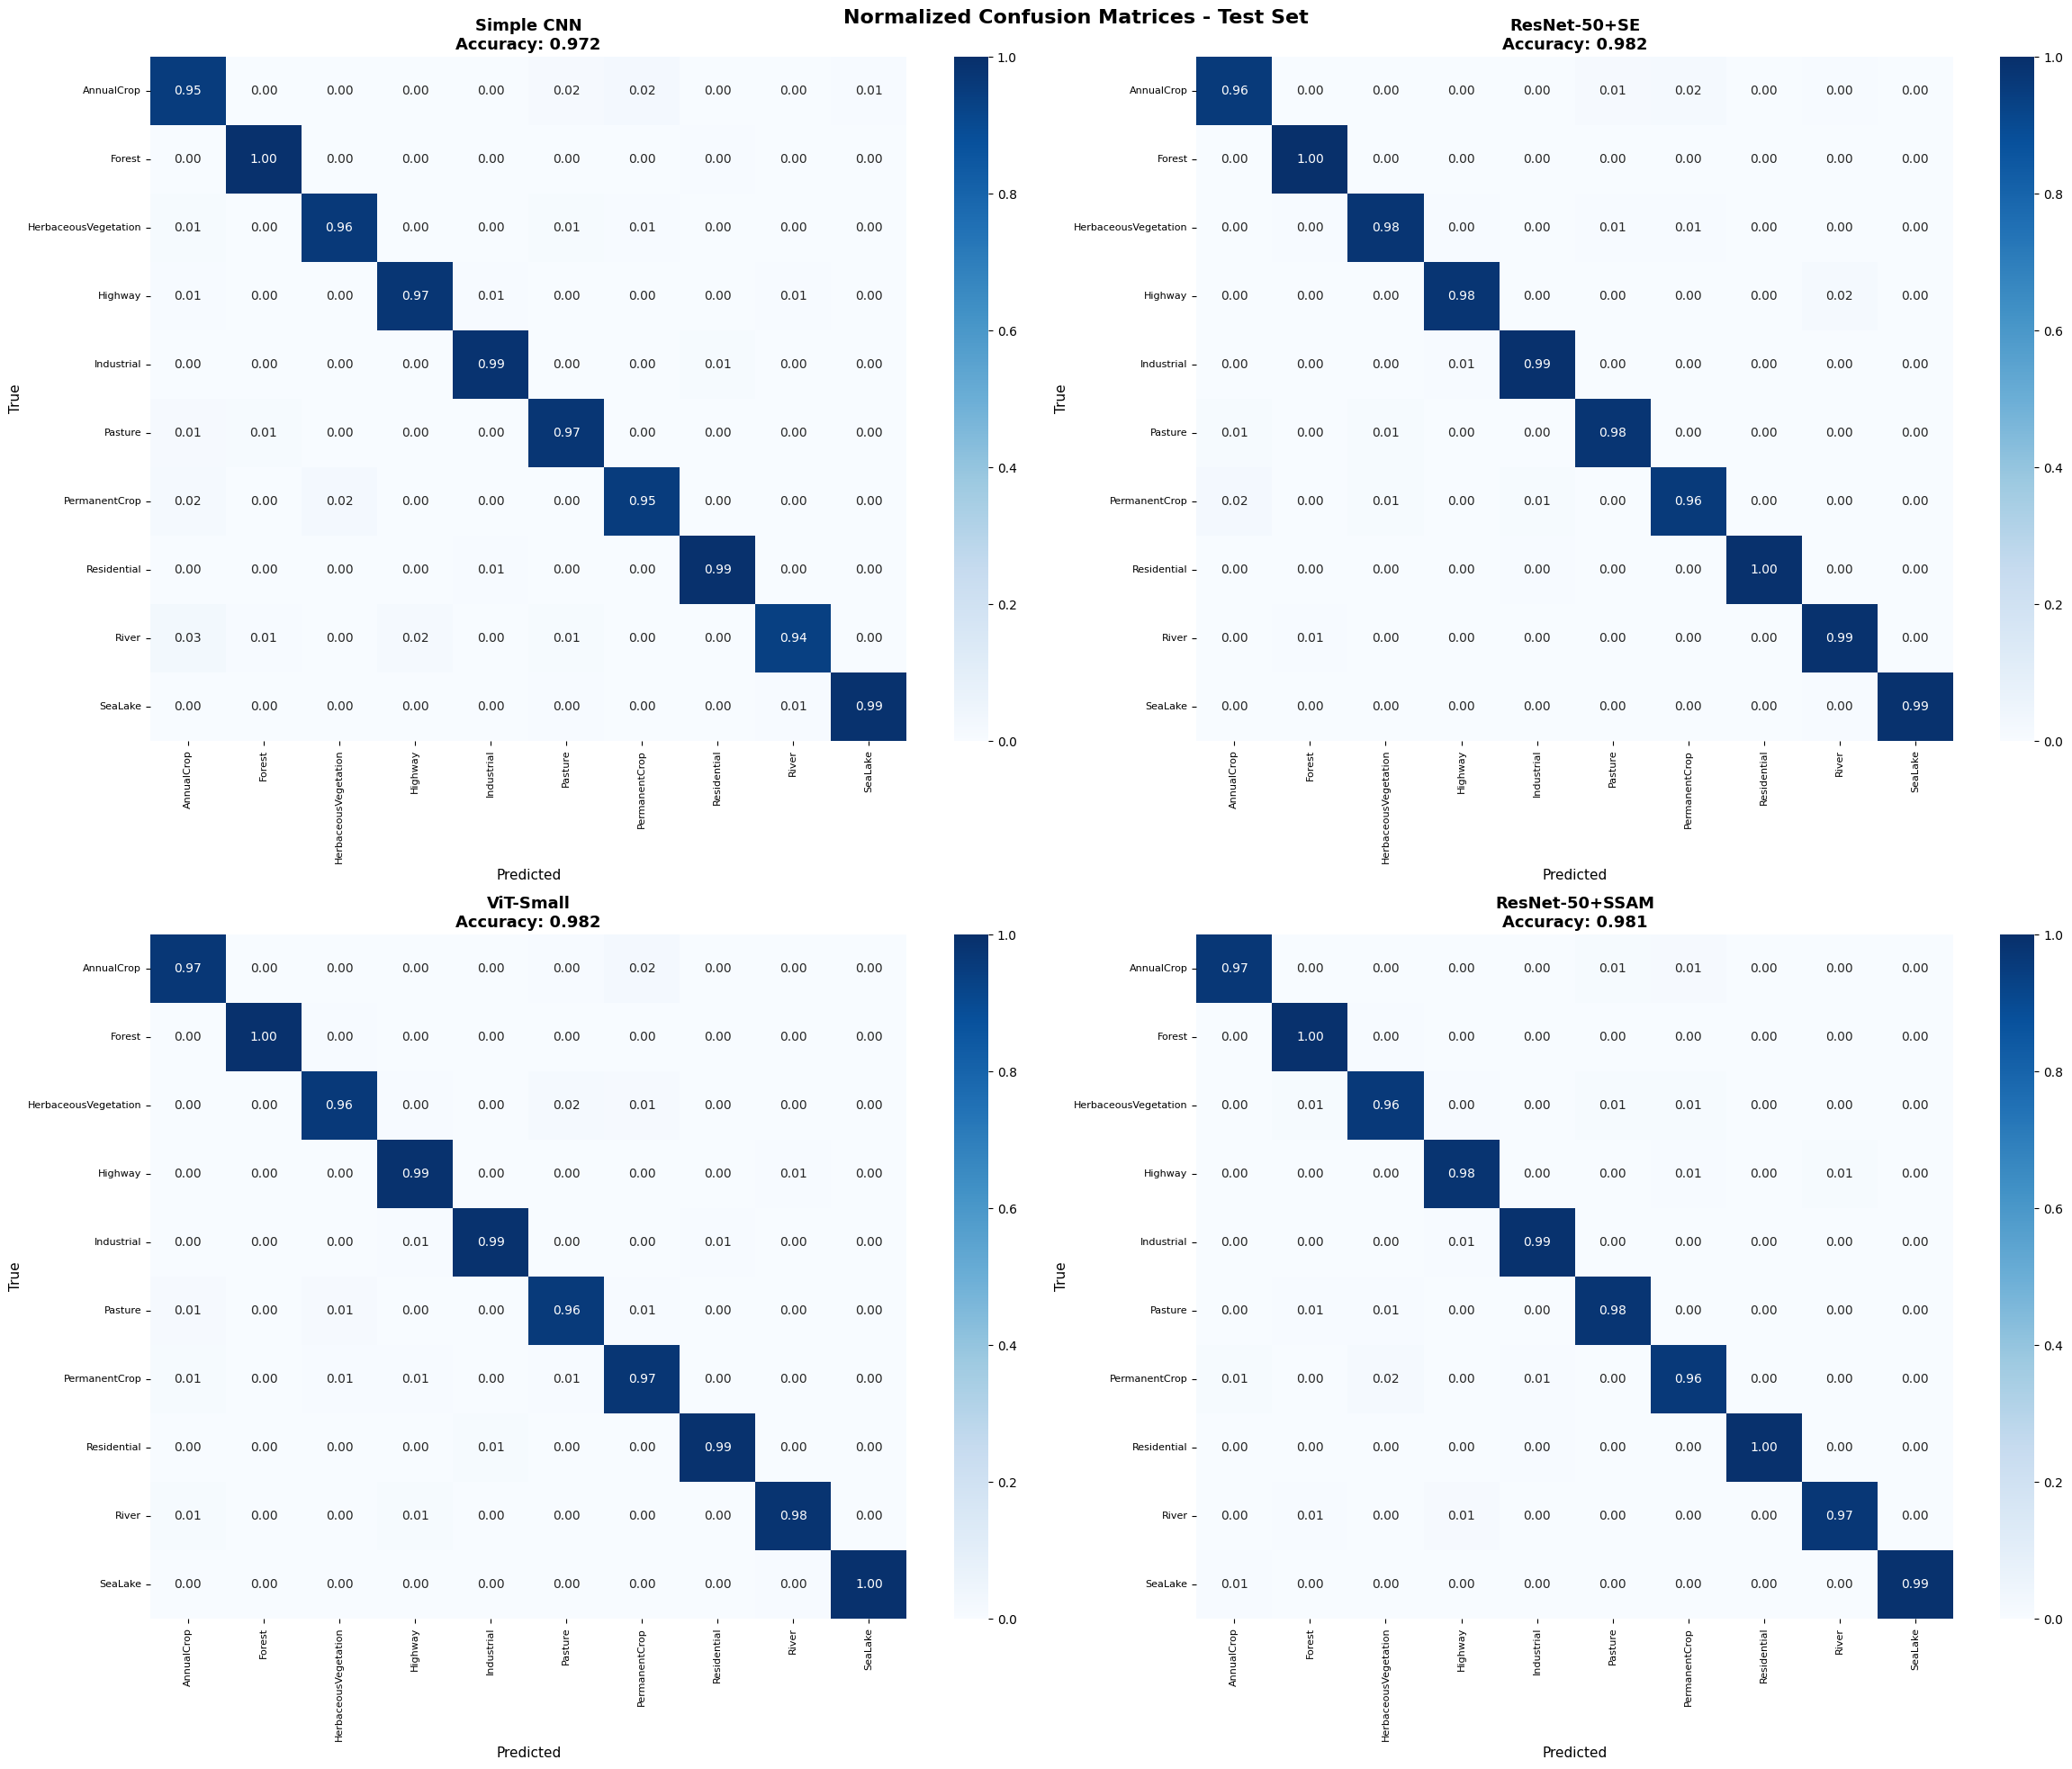

In [ ]:
n_models = len(test_metrics)
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

for idx, (name, m) in enumerate(test_metrics.items()):
    if idx >= 4: break
    cm = confusion_matrix(m['labels'], m['preds'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[idx], vmin=0, vmax=1)
    axes[idx].set_title(f'{name}\nAccuracy: {m["accuracy"]:.3f}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('True', fontsize=11)
    axes[idx].tick_params(axis='both', labelsize=8)

# Hide unused axes
for idx in range(n_models, 4):
    axes[idx].set_visible(False)

plt.suptitle('Normalized Confusion Matrices - Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Detailed Classification Report (Best Model)

In [ ]:
best_name = max(test_metrics, key=lambda x: test_metrics[x]['accuracy'])
best_m = test_metrics[best_name]

print(f"Best Model: {best_name} (Accuracy: {best_m['accuracy']:.4f})")
print("="*60)
report = classification_report(best_m['labels'], best_m['preds'],
                                target_names=CLASS_NAMES, digits=4)
print(report)

# Save report
with open(os.path.join(METRICS_DIR, 'best_model_report.txt'), 'w') as f:
    f.write(f"Best Model: {best_name}\n")
    f.write(f"Accuracy: {best_m['accuracy']:.4f}\n\n")
    f.write(report)

Best Model: ResNet-50+SE (Accuracy: 0.9820)
                      precision    recall  f1-score   support

          AnnualCrop     0.9729    0.9578    0.9653       450
              Forest     0.9846    0.9978    0.9912       450
HerbaceousVegetation     0.9821    0.9778    0.9800       450
             Highway     0.9839    0.9787    0.9813       375
          Industrial     0.9842    0.9947    0.9894       375
             Pasture     0.9702    0.9767    0.9734       300
       PermanentCrop     0.9677    0.9573    0.9625       375
         Residential     1.0000    0.9956    0.9978       450
               River     0.9712    0.9893    0.9802       375
             SeaLake     0.9955    0.9911    0.9933       450

            accuracy                         0.9820      4050
           macro avg     0.9812    0.9817    0.9814      4050
        weighted avg     0.9820    0.9820    0.9820      4050



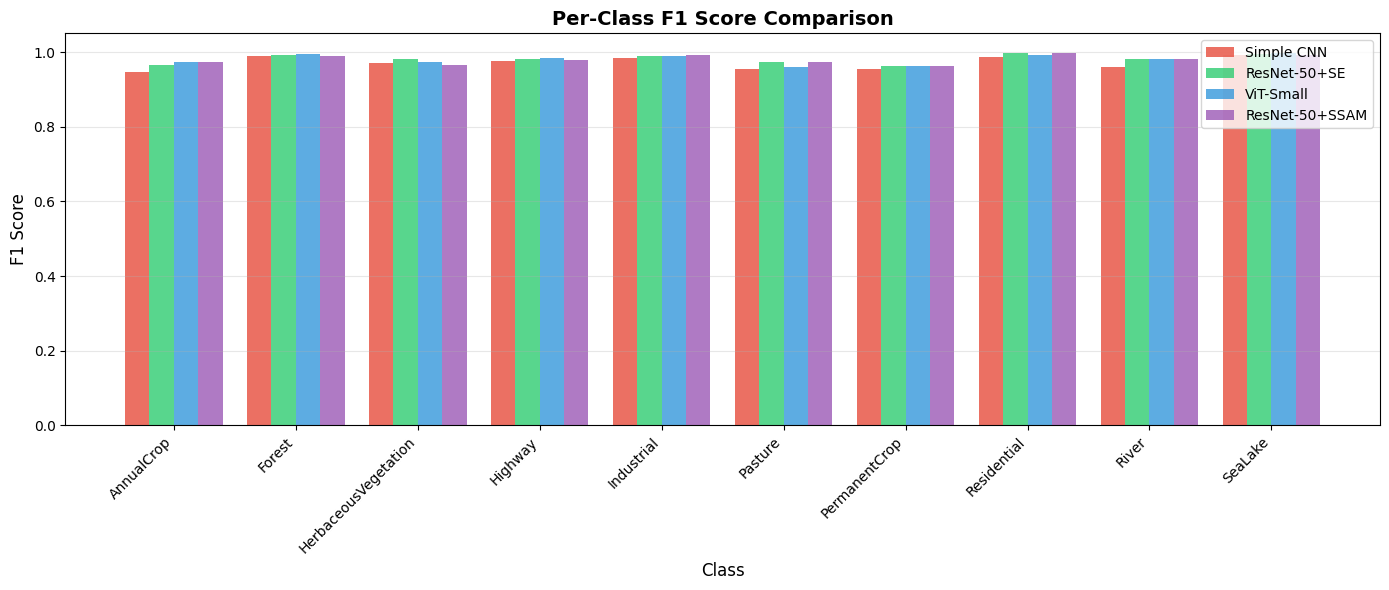

In [8]:
# Per-class F1 comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(CLASS_NAMES))
width = 0.2
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

for i, (name, m) in enumerate(test_metrics.items()):
    _, _, f1_per_class, _ = precision_recall_fscore_support(m['labels'], m['preds'], average=None)
    ax.bar(x + i * width, f1_per_class, width, label=name, color=colors[i], alpha=0.8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

- Evaluated all 4 models on the held-out test set
- Generated confusion matrices and per-class F1 comparison
- Saved comparison CSV and best model classification report

**Next:** Run `04_Ablation_Studies.ipynb` on Colab, then `05_Interpretability.ipynb` locally.